# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('../Lecture/Week 1/assets/titanic_passengers.csv')

# Create age categories
df['AgeGroup'] = 'Unknown'

df.loc[df['Age'] < 18, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] >= 18) & (df['Age'] < 40), 'AgeGroup'] = 'Young Adult'
df.loc[(df['Age'] >= 40) & (df['Age'] < 60), 'AgeGroup'] = 'Middle Age'
df.loc[df['Age'] >= 60, 'AgeGroup'] = 'Senior'

# Create fare categories
df['FareGroup'] = 'Unknown'

df.loc[df['Fare'] < 10, 'FareGroup'] = 'Low Fare'
df.loc[(df['Fare'] >= 10) & (df['Fare'] < 50), 'FareGroup'] = 'Medium Fare'
df.loc[df['Fare'] >= 50, 'FareGroup'] = 'High Fare'

# Create travel companion totals
df['TravelCompanions'] = df['SibSp'] + df['Parch']

# Categorize travel companions
df['CompanionGroup'] = 'Unknown'

df.loc[df['TravelCompanions'] == 0, 'CompanionGroup'] = 'Alone'
df.loc[(df['TravelCompanions'] >= 1) & (df['TravelCompanions'] <= 3), 'CompanionGroup'] = 'Small Group'
df.loc[df['TravelCompanions'] >= 4, 'CompanionGroup'] = 'Large Group'

# Preview
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,FareGroup,TravelCompanions,CompanionGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult,Low Fare,1,Small Group
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Young Adult,High Fare,1,Small Group
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult,Low Fare,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Young Adult,High Fare,1,Small Group
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Young Adult,Low Fare,0,Alone


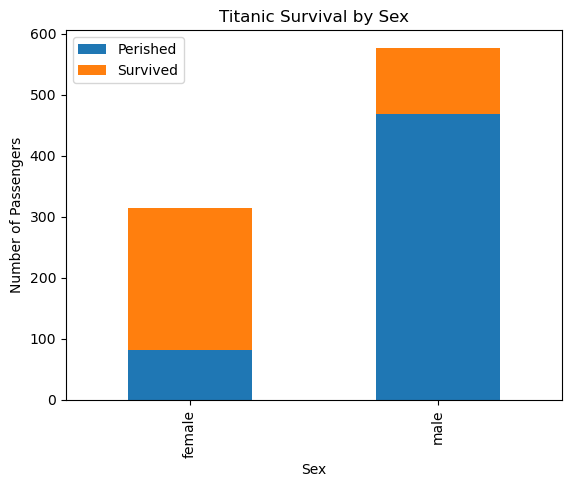

In [5]:
sex_survival = pd.crosstab(df['Sex'], df['Survived'])

sex_survival.plot(kind='bar', stacked=True)

plt.title('Titanic Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.legend(['Perished', 'Survived'])

plt.show()

Female passengers had a much higher survival rate than male passengers, making sex a major factor in survival likelihood.

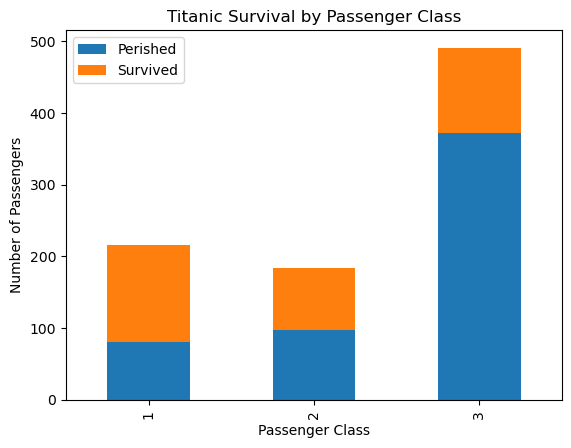

In [8]:
class_survival = pd.crosstab(df['Pclass'], df['Survived'])

class_survival.plot(kind='bar', stacked=True)

plt.title('Titanic Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(['Perished', 'Survived'])

plt.show()

First-class passengers had the highest survival rates, while third-class passengers experienced the highest number of deaths, indicating passenger class strongly influenced survival outcomes.

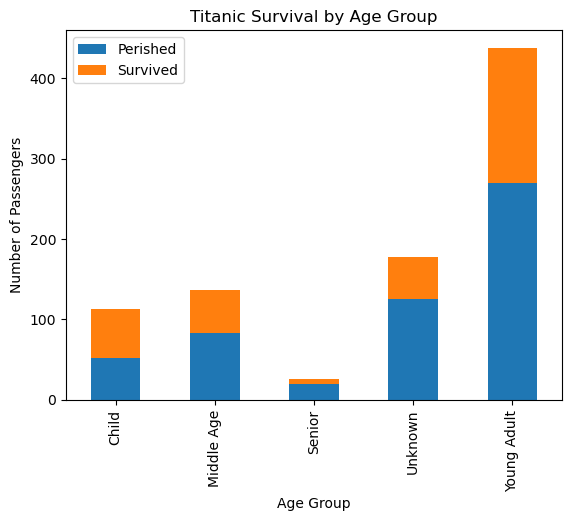

In [11]:
age_survival = pd.crosstab(df['AgeGroup'], df['Survived'])

age_survival.plot(kind='bar', stacked=True)

plt.title('Titanic Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.legend(['Perished', 'Survived'])

plt.show()

Age appears to have influenced survival outcomes, with children generally showing stronger survival rates compared to some adult age groups.

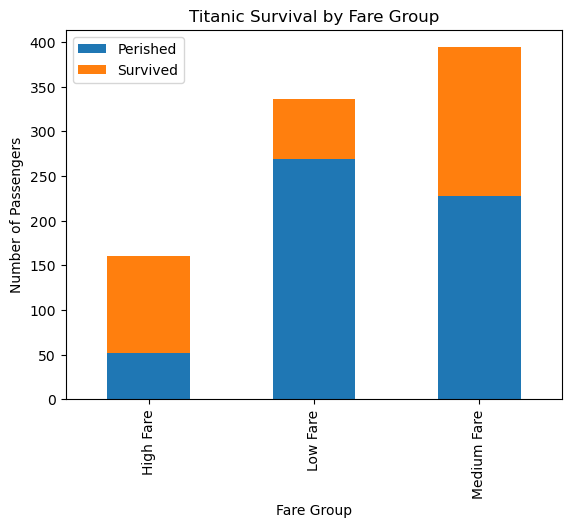

In [14]:
fare_survival = pd.crosstab(df['FareGroup'], df['Survived'])

fare_survival.plot(kind='bar', stacked=True)

plt.title('Titanic Survival by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Number of Passengers')
plt.legend(['Perished', 'Survived'])

plt.show()

Passengers who paid higher fares generally showed stronger survival outcomes, suggesting that wealth and access associated with ticket price influenced survival chances.

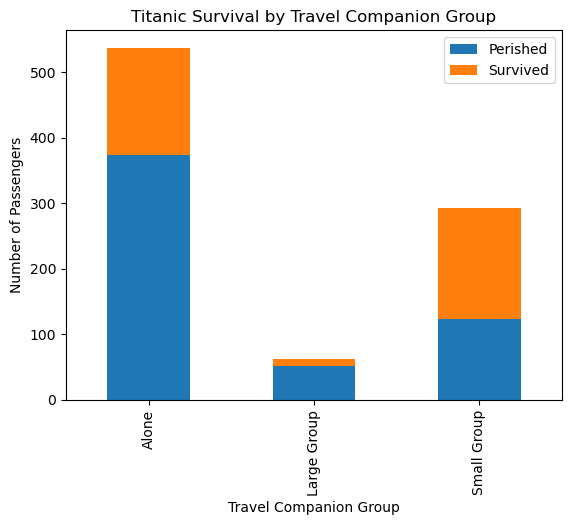

In [17]:
companion_survival = pd.crosstab(df['CompanionGroup'], df['Survived'])

companion_survival.plot(kind='bar', stacked=True)

plt.title('Titanic Survival by Travel Companion Group')
plt.xlabel('Travel Companion Group')
plt.ylabel('Number of Passengers')
plt.legend(['Perished', 'Survived'])

plt.show()

Passengers traveling in smaller groups appeared to have stronger survival outcomes compared to those traveling alone or in larger groups, suggesting group size may have influenced evacuation chances.

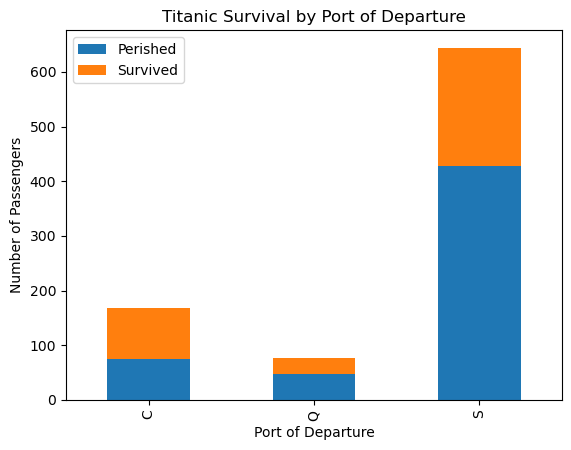

In [20]:
embarked_survival = pd.crosstab(df['Embarked'], df['Survived'])

embarked_survival.plot(kind='bar', stacked=True)

plt.title('Titanic Survival by Port of Departure')
plt.xlabel('Port of Departure')
plt.ylabel('Number of Passengers')
plt.legend(['Perished', 'Survived'])

plt.show()

Passenger survival varied by port of departure, suggesting embarkation location may have correlated with passenger demographics such as ticket class and wealth.

## Most Likely to Survive Character Profile

The passenger most likely to survive would likely be a young adult female traveling in first class with a high fare ticket, accompanied by a small group of family or companions, and embarking from Cherbourg. The data suggests these traits were associated with the strongest survival outcomes.

## Least Likely to Survive Character Profile

The passenger least likely to survive would likely be a young adult male traveling alone in third class with a low fare ticket, embarking from Southampton. These characteristics consistently showed the poorest survival outcomes in the dataset.

In [25]:
most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['AgeGroup'] == 'Young Adult') &
    (df['FareGroup'] == 'High Fare') &
    (df['CompanionGroup'] == 'Small Group') &
    (df['Embarked'] == 'C')
]

least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['AgeGroup'] == 'Young Adult') &
    (df['FareGroup'] == 'Low Fare') &
    (df['CompanionGroup'] == 'Alone') &
    (df['Embarked'] == 'S')
]

print("Most likely match:")
print(most_likely['Name'].head())

print("\nLeast likely match:")
print(least_likely['Name'].head())

Most likely match:
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
215                              Newell, Miss. Madeleine
291              Bishop, Mrs. Dickinson H (Helen Walton)
393                               Newell, Miss. Marjorie
581    Thayer, Mrs. John Borland (Marian Longstreth M...
Name: Name, dtype: object

Least likely match:
4           Allen, Mr. William Henry
12    Saundercock, Mr. William Henry
37          Cann, Mr. Ernest Charles
51      Nosworthy, Mr. Richard Cater
67          Crease, Mr. Ernest James
Name: Name, dtype: object


In [27]:
print("Most Likely Real Passenger Match:")
print("Cummings, Mrs. John Bradley (Florence Briggs Thayer)")

print("\nLeast Likely Real Passenger Match:")
print("Allen, Mr. William Henry")

Most Likely Real Passenger Match:
Cummings, Mrs. John Bradley (Florence Briggs Thayer)

Least Likely Real Passenger Match:
Allen, Mr. William Henry


## Real Passenger Matches and Interesting Facts

### Most Likely to Survive Match:
**Cummings, Mrs. John Bradley (Florence Briggs Thayer)**

Florence Briggs Thayer Cummings survived the Titanic disaster in Lifeboat 4 at just 18 years old. She went on to live for many decades after the sinking, making her one of the survivors who carried firsthand memories of the disaster into modern history.

### Least Likely to Survive Match:
**Allen, Mr. William Henry**

William Henry Allen was a 29-year-old laborer from Southampton, England, traveling alone as a third-class passenger in search of a new life in the United States. He tragically perished in the sinking.